# SDOF and MDOF Model Calibration and Compilation

## Introduction

This Jupyter Notebook presents a structured workflow for the calibration and modelling of simplified/idealised structural models in OpenSees, namely single- and multi-degree-of-freedom systems. 

The main applications of this notebook are:

1. **Compile and construct SDOF Models in OpenSees**: Construction of SDOF representations by defining essential structural properties such as mass, height and nonlinear capacity. The first example includes an implementation of nonlinear force-deformation capacity to capture post-elastic behavior powered by OpenseesPy.

2. **Compile and construct MDOF Stick-and-Mass Models in OpenSees**: Construction of MDOF stick-and-mass models, in which each floor is represented as a lumped mass connected by nonlinear springs capturing lateral stiffness and yielding. The second example requires specification of building properties including mass distribution, inter-story stiffness, damping, and nonlinear response characteristics and the implementation of nonlinear force-deformation to capture post-elastic behavior powered by OpenseesPy.

3. **Calibrate and compile MDOF Models Based on SDOF Capacity and Parameters**: The third example aims at establishing consistency between the SDOF and MDOF representations by calibrating inter-story properties of the MDOF model using target capacity curves derived from the SDOF model. Adjustment of parameters such as stiffness, yield strength, and post-yield behavior to ensure that the global capacity of the MDOF model reflects that of the reference SDOF system.

This integrated workflow provides a foundation for both simplified and detailed seismic performance assessment, while demonstrating how calibrated MDOF models can be informed by equivalent SDOF capacities for more accurate regional or portfolio-level evaluations.

---

## References

[1] Priestley, M., Calvi, G. and Kowalski, M. (2007) Displacement-based seismic design of structures. IUSS Press, Pavia.

[2] Lu X, McKenna F, Cheng Q, Xu Z, Zeng X, Mahin SA. An open-source framework for regional earthquake loss estimation using the city-scale nonlinear time history analysis. Earthquake Spectra. 2020;36(2):806-831. doi:10.1177/8755293019891724


## Initialize Libraries ##

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import the classes necessary for structural analysis
from openquake.vmtk.units         import units             # OQ-VMTK units class
from openquake.vmtk.modeller      import modeller          # OQ-VMTK numerical modelling and analysis module
from openquake.vmtk.calibration   import calibrate_model   # OQ-VMTK sdof-to-mdof calibration module

## Example 1: Compiling an SDOF model ##

### Required SDOF Modelling Input Parameters ###

The following parameters are required to compile an SDOF model using the `modeller` class:

- **`number_storeys`**: Set to `1` for an SDOF oscillator. This tells the modeller to construct a single node-spring-mass system.
- **`storey_heights`**: A single-element list containing the effective height of the SDOF oscillator in metres. This is used to define the node geometry in OpenSees.
- **`floor_mass`**: A single-element list containing the lumped mass in tonnes. For a unit-mass SDOF this is `[1.0]`, consistent with a capacity curve expressed in spectral units (Sa in g, Sd in m).
- **`sdof_capacity`**: A 2 × n array defining the nonlinear force-deformation backbone of the oscillator. The first row contains spectral displacements Sd in metres and the second row contains spectral accelerations Sa in g. Between 2 and 4 points are supported (bilinear to quadrilinear).
- **`sdof_degradation`**: Boolean flag controlling hysteretic degradation in the Pinching4 material. Set to `True` to activate stiffness, strength and pinching degradation; `False` for a non-degrading backbone.

In [2]:
# Number of storeys
number_storeys = 1

# Relative storey heights list [in m]
storey_heights = [2.80] 

# Relative floor masses list [in tonnes]
floor_mass = [1.0] 

# SDOF capacity with a quadrilinear backbone
sdof_capacity = np.array([[0.00060789, 0.00486316, 0.02420000, 0.04353684],   # spectral displacement [in m]
                          [0.10315200, 0.20630401, 0.12378241, 0.12502023]])  # spectral acceleration [in g]
                         
# Flag to activate default stiffness-strength degradation and pinching4
sdof_degradation = False

### Compile SDOF Oscillator in OpenSees ###

The SDOF oscillator is assembled by passing the structural properties defined above to the `modeller` class. Internally, OpenSees constructs a single zero-length spring element connecting the fixed base to a lumped floor mass. The nonlinear spring is characterised by a Pinching4 hysteretic material whose backbone is derived directly from the SDOF capacity curve. Once compiled, the model is ready for gravity analysis, modal analysis, or any of the supported analysis routines (SPO, CPO, NRHA).

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance


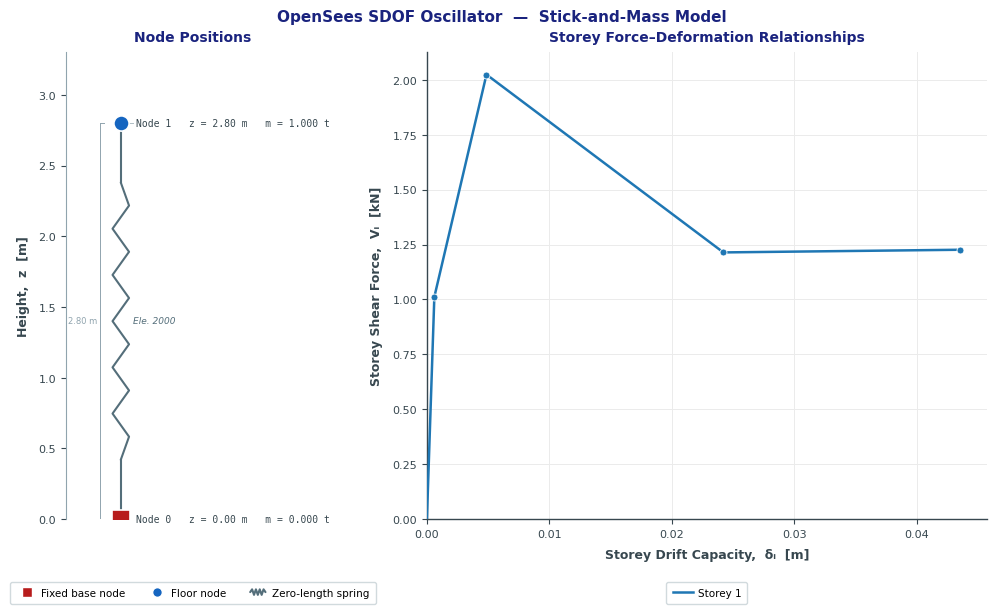

In [3]:
# Initialise the modeller class with model parameters    
model = modeller(number_storeys,
                 storey_heights,
                 floor_mass,
                 sdof_capacity[0, :][np.newaxis, :],          
                 (sdof_capacity[1, :]*units.g)[np.newaxis, :],
                 sdof_degradation)                            

# Compile the SDOF model in OpenSeesPy
model.compile_model()                                         

# Visualise the model 
model.plot_model(pFlag = True,
                 export_path = './out/sdof_model.png')                             

## Example 2: Compiling an MDOF Stick-and-Mass Model ##

### Required MDOF Modelling Input Parameters ###

The following parameters are required to compile an MDOF stick-and-mass model using the `modeller` class:

- **`number_storeys`**: Integer number of storeys. Defines the number of floor nodes and zero-length spring elements in the OpenSees model.
- **`storey_heights`**: List of storey heights in metres, one entry per storey from ground to roof. Used to position floor nodes vertically in OpenSees.
- **`floor_masses`**: List of lumped floor masses in tonnes, one entry per storey. Each mass is assigned to the corresponding floor node as a translational inertia in both horizontal directions.
- **`storey_drifts`**: Array of shape (number_storeys × n_points) containing the inter-storey drift backbone for each storey in metres. Each row defines the deformation capacity of the spring at that storey level.
- **`storey_forces`**: Array of shape (number_storeys × n_points) containing the storey shear backbone for each storey in kN. Each row defines the force capacity of the spring at that storey level, and must be consistent in length with `storey_drifts`.
- **`mdof_degradation`**: Boolean flag controlling hysteretic degradation in the Pinching4 material. Set to `True` to activate stiffness, strength and pinching degradation; `False` for a non-degrading backbone.

In [4]:
# Number of storeys
number_storeys = 3 

# Relative floor heights list [in m]
storey_heights = [2.80, 3.00, 3.00]

# Relative floor masses list
floor_masses = [0.75, 0.75, 0.75] # Lumped masses at each floor [in tonnes]

# MDOF storey drift capacities with a quadrilinear backbone [in m]
storey_drifts = np.array([[0.005, 0.010, 0.020, 0.030],   # 1st storey drift capacity
                          [0.006, 0.012, 0.025, 0.035],   # 2nd storey drift capacity
                          [0.007, 0.014, 0.030, 0.040]])  # 3rd storey drift capacity

# MDOF storey shear capacities with a quadrilinear backbone [in kN]
storey_forces = np.array([[1.00, 2.00, 1.50, 1.20],               # 1st storey shear capacity
                          [1.20, 2.40, 1.80, 1.40],               # 2nd storey shear capacity
                          [1.40, 2.80, 2.00, 1.60]]) * units.kN   # 3rd storey shear capacity

# Flag to activate default stiffness-strength degradation and pinching4
mdof_degradation = False

### Compile MDOF Stick-and-Mass Model in OpenSees ###

The MDOF stick-and-mass model is assembled by passing the per-storey structural properties to the `modeller` class. OpenSees constructs a vertical chain of zero-length spring elements, one per storey, each connecting adjacent floor nodes. Lumped masses are assigned at every floor level, with the roof carrying a reduced share. Each spring is characterised by a Pinching4 hysteretic material whose backbone is defined by the storey drift and storey shear capacity arrays provided above. The resulting model captures inter-storey yielding, stiffness degradation (if enabled), and strength loss, and is ready for modal analysis, static pushover, or nonlinear time-history analysis.

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 3, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 3, which is greater than the tolerance


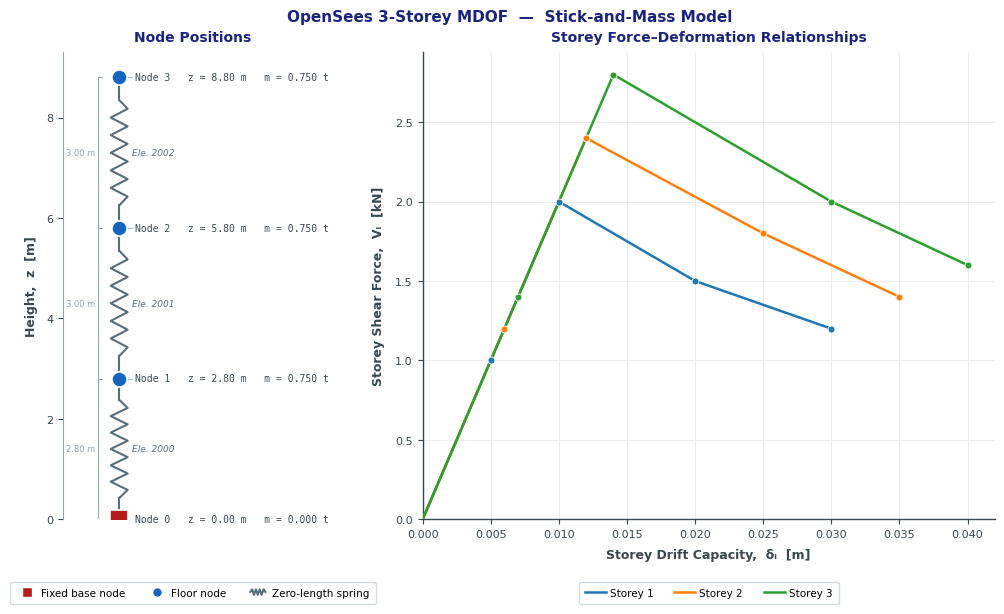

In [5]:
# Initialise the modeller class with model parameters
model = modeller(number_storeys,
                 storey_heights,
                 floor_masses,
                 storey_drifts,          
                 storey_forces,         
                 mdof_degradation) 

# Compile the MDOF model in OpenSeesPy   
model.compile_model()                                         

# Visualise the model 
model.plot_model(pFlag = True,
                 export_path = './out/mdof_model_1.png')                                 

## Example 3: Calibrating and Compiling an MDOF Stick-and-Mass Model Based on SDOF Capacity ##

### Required SDOF Modelling Input Parameters for MDOF Model Calibration ###

In [6]:
# Number of storeys
number_storeys = 2

# Relative floor heights list
storey_heights = [2.80, 2.80]

# SDOF capacity with a quadrilinear backbone
sdof_capacity = np.array([[0.00060789, 0.00486316, 0.02420000, 0.04353684],     # spectral displacement [in m]
                          [0.10315200, 0.20630401, 0.12378241, 0.12502023]]).T  # spectral acceleration [in g]

# Soft-storey mechanism flag
isSOS = False

# Degradation flag 
mdof_degradation = False

### Calibrate an MDOF Model based on SDOF Capacity ###

The `calibrate_model` function derives consistent per-storey force-deformation relationships for the MDOF model directly from the SDOF spectral capacity curve. The calibration proceeds in three steps. First, a mass matrix (unit total mass) and a relative stiffness profile are constructed from the building geometry, then scaled analytically so that the fundamental period of the MDOF system matches the period implied by the first point of the SDOF capacity curve, T* = 2π√(Sd₀ / (Sa₀ · g)). Second, the first mode shape and participation factors are extracted from this scaled system and used to distribute the SDOF base shear and displacement into per-storey shear and drift backbones using the displacement-based design principles [1, 2], applying a uniform-ductility assumption so that all storeys share the same displacement backbone. Third, the storey forces are rescaled to ensure that the spring stiffness implied by each backbone is exactly consistent with the scaled stiffness matrix, guaranteeing that the OpenSees model reproduces T* without any iterative correction. The function returns the floor masses, storey drift backbones, storey force backbones, the first mode shape, and a metadata dictionary containing modal properties and the target roof displacement array.

The following parameters are required as inputs to the `calibrate_model` function. Note that the floor masses, storey drifts and storey forces are not specified manually here — they are derived automatically by the calibration procedure and passed directly to the `modeller` class.

- **`number_storeys`**: Integer number of storeys in the target MDOF building. Controls the size of the mass and stiffness matrices used internally during calibration.
- **`storey_heights`**: List of storey heights in metres, one entry per storey. When provided, the calibration also builds an OpenSees model and runs a static pushover for verification. If omitted, only the analytical backbone is returned.
- **`sdof_capacity`**: Array of shape (n_points × 2) defining the SDOF spectral capacity curve. Column 0 contains spectral displacements Sd in metres and column 1 contains spectral accelerations Sa in g. The first point defines the yield condition and is used to derive the target fundamental period T* = 2π√(Sd₀ / (Sa₀ · g)).
- **`isSOS`**: Boolean flag indicating whether a soft-storey mechanism is expected. When `True`, the ground-floor spring stiffness is reduced by a factor of 0.35 to represent a pilotis or weak ground storey.
- **`mdof_degradation`**: Boolean flag passed to the `modeller` class after calibration. Controls whether the Pinching4 hysteretic material includes stiffness, strength and pinching degradation.

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Stopped because of load factor below zero


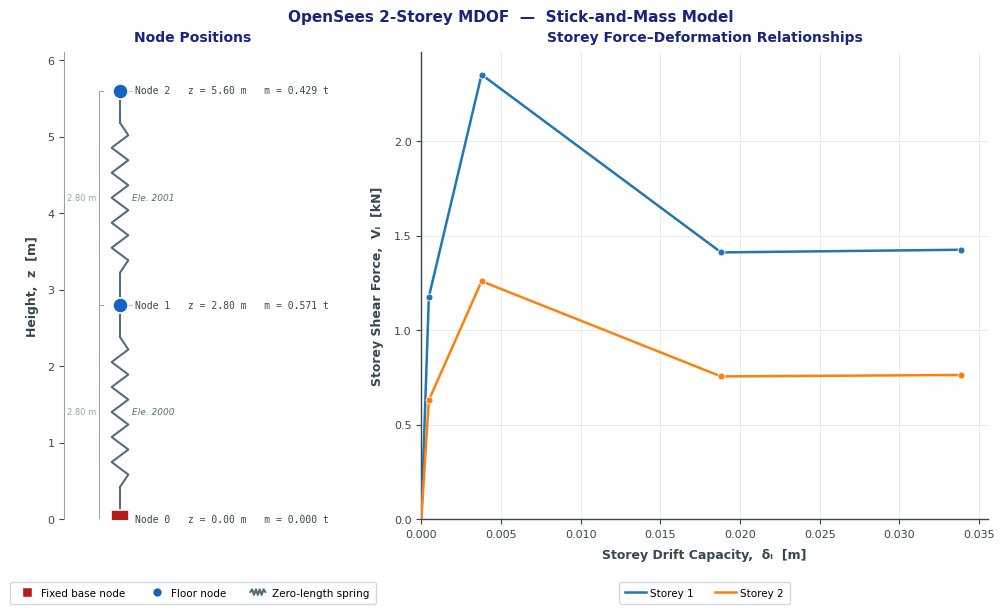

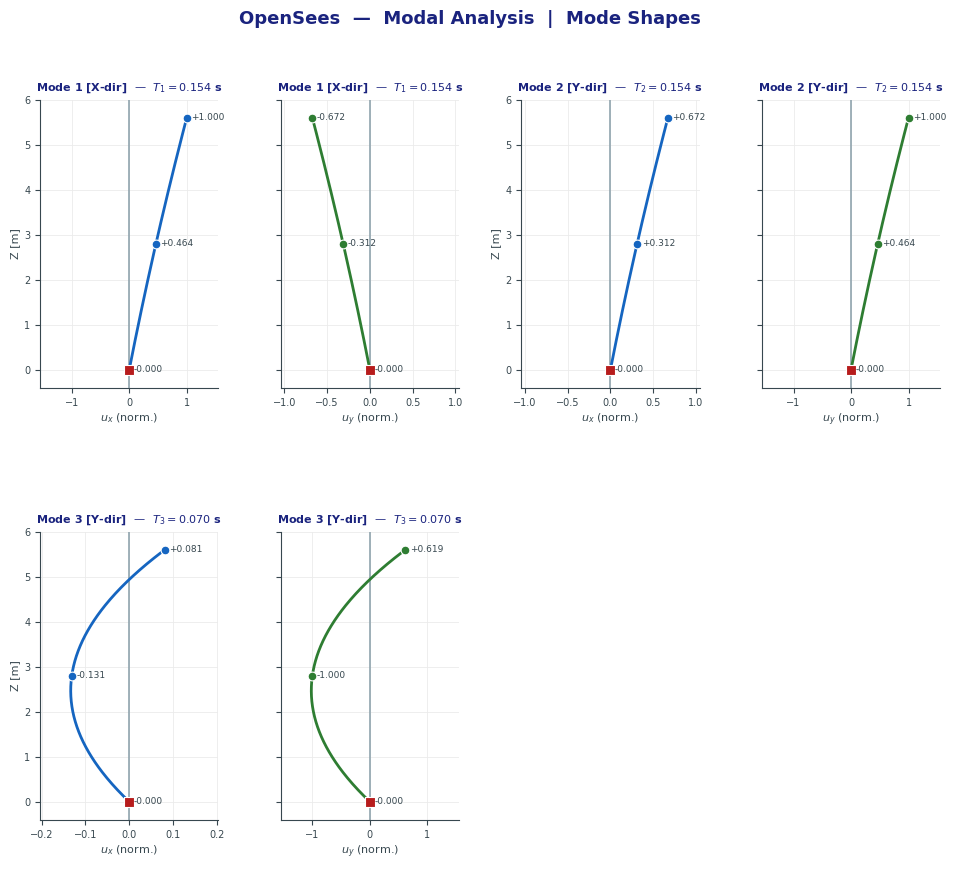

T1 = 0.1540 s  (target: 0.1540 s)
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Stopped because of load factor below zero


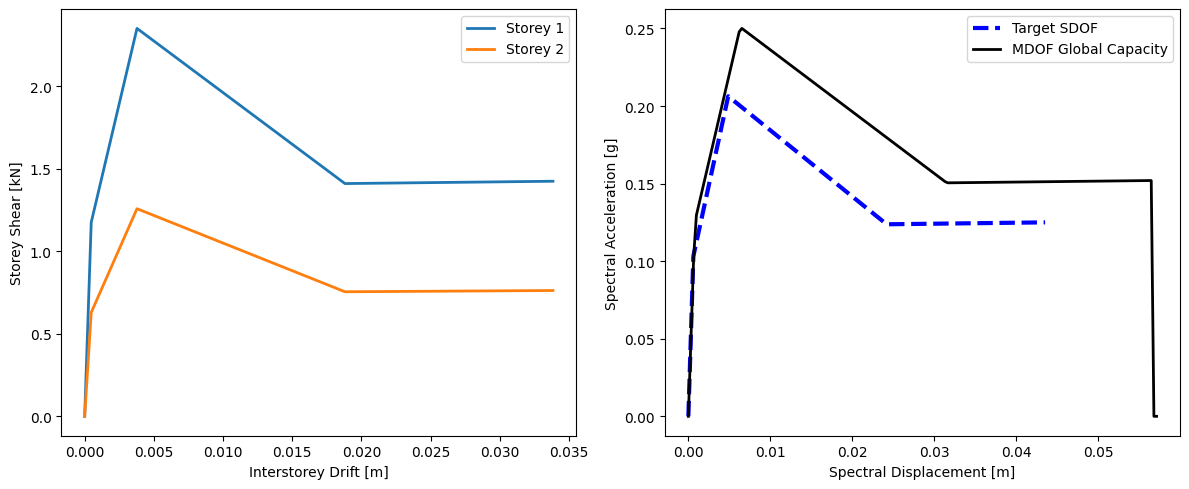

In [7]:
# Calibrate the model
floor_masses, storey_drifts, storey_forces, mdof_phi, meta = calibrate_model(number_storeys,
                                                                             sdof_capacity,
                                                                             isSOS=isSOS,
                                                                             storey_heights=storey_heights,
                                                                             verbose=False)

# Post-calibration metadata
Gamma = meta['Gamma']   # 1st mode participation factor
M_eff = meta['M_eff']   # Effective modal mass

# Compile model based on calibration results
model = modeller(number_storeys,
                 storey_heights,
                 floor_masses,
                 storey_drifts,
                 storey_forces * 9.81,
                 mdof_degradation)

# Compile the MDOF model in OpenSeesPy   
model.compile_model()                                         

# Visualise the model 
model.plot_model(pFlag = True,
                 export_path = './out/mdof_model_2.png')       

# Run modal analysis and verify period
T_star = 2*np.pi * np.sqrt(sdof_capacity[0,0] / (sdof_capacity[0,1] * 9.81))
num_modes = 1 if number_storeys == 1 else 3
T, _ = model.do_modal_analysis(num_modes=num_modes)
print(f"T1 = {T[0]:.4f} s  (target: {T_star:.4f} s)")

# Run pushover
u_roof_target = meta['u_roof_target']
u_roof_yield  = u_roof_target[0]
u_roof_ult    = u_roof_target[-1]
disp_scale    = max((u_roof_ult * 1.5) / u_roof_yield, 2.0)
spo_results = model.do_spo_analysis(ref_disp=u_roof_yield,
                                    disp_scale_factor=disp_scale,
                                    push_dir=1,
                                    phi=mdof_phi,
                                    pFlag=False)

# Unpack SPO results
spo_roof = spo_results['spo_disps'][:, -1]  # Roof displacement [m]
spo_rxn  = spo_results['spo_rxn']           # Base shear [kN]

# Convert MDOF pushover to SDOF coordinates
spo_Sd = spo_roof / (Gamma * mdof_phi[-1])
spo_Sa = spo_rxn  / (M_eff * 9.81)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: Storey backbones
ax = axes[0]
for i in range(number_storeys):
    ax.plot(np.concatenate(([0.0], storey_drifts[i, :])),
            np.concatenate(([0.0], storey_forces[i, :] * 9.81)),
            label=f'Storey {i+1}', linewidth=2)
ax.set_xlabel('Interstorey Drift [m]')
ax.set_ylabel('Storey Shear [kN]')
ax.legend()

# Panel 2: SDOF vs MDOF capacity
ax = axes[1]
ax.plot(np.concatenate(([0.0], sdof_capacity[:, 0])),
        np.concatenate(([0.0], sdof_capacity[:, 1])), 'b--', lw=3, label='Target SDOF')
ax.plot(np.concatenate(([0.0], spo_Sd)),
        np.concatenate(([0.0], spo_Sa)), 'k-', lw=2, label='MDOF Global Capacity')
ax.set_xlabel('Spectral Displacement [m]')
ax.set_ylabel('Spectral Acceleration [g]')
ax.legend()

plt.tight_layout()
plt.show()